In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Telco_Customer_Churn.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,70.70,151.65,Yes


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
''' Task 1: Count how many customers have Churn = 'Yes' and how many have Churn = 'No' '''

churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
''' Task 2: Show the count of churned customers for each contract type '''

pivot_table = df.groupby('Contract').agg(Count_Churn_Custm = ('Churn', lambda x: (x == 'Yes').sum()))
pivot_table                                   

,Count_Churn_Custm
Contract,
Month-to-month,1655
One year,166
Two year,48


In [ ]:
''' Task 3: Calculate the average MonthlyCharges for customers who churned versus those who did not '''

churned = df[df['Churn']=='Yes'].groupby('Churn')['MonthlyCharges'].mean()
not_churned = df[df['Churn']=='No'].groupby('Churn')['MonthlyCharges'].mean()

print("Average Monthly Charges for Churned Customers: ", churned)
print("Average Monthly Charges for Non-Churned Customers: ", not_churned)


Average Monthly Charges for Churned Customers:  Churn
Yes    74.441332
Name: MonthlyCharges, dtype: float64
Average Monthly Charges for Non-Churned Customers:  Churn
No    61.265124
Name: MonthlyCharges, dtype: float64
Churn
Yes    74.441332
Name: MonthlyCharges, dtype: float64


Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


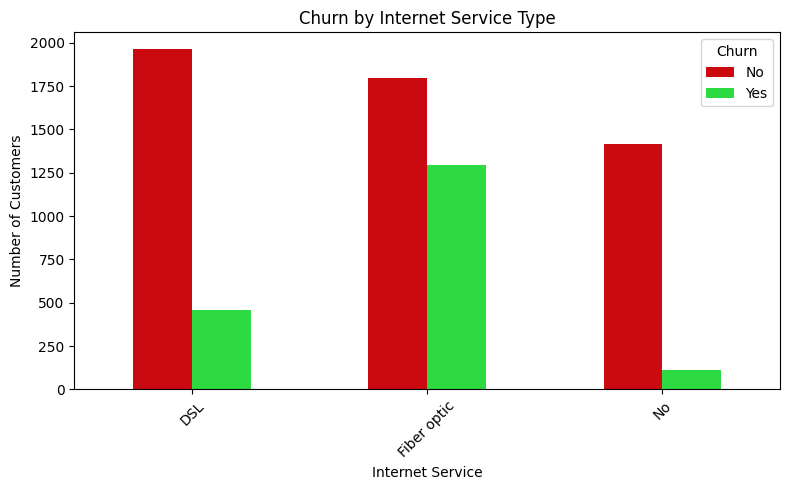

In [31]:
''' Task 4: Create a bar chart in Excel that compares the number of churned vs non-churned customers for each InternetService type (DSL, Fiber optic, No) '''

churn_service_counts = (
    df.groupby(["InternetService", "Churn"])
    .size()
    .unstack(fill_value=0)   # puts Churn=Yes and Churn=No side by side
)

print(churn_service_counts)

churn_service_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=[ "#CA0A10","#2DDA41"]  # blue for No, red for Yes
)

plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.xticks(rotation=45)
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [48]:
''' Task 5: Use Excel's CORREL function to check if there is a correlation between Tenure and Churn (convert Churn 'Yes' to 1 
and 'No' to 0 in a new column first), and interpret the result '''

df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0}).reset_index(drop=True)
correlation = df[['Churn_numeric','tenure']].corr()
print(correlation)

""" Interpretation:-

1. Negative correlation (-0.35) → As tenure increases, the likelihood of churn decreases.
   Customers who have been with the company longer are less likely to churn.
   Conversely, newer customers (shorter tenure) are more likely to churn.

2. Strength (-0.35) → This is a moderate negative correlation.
   It's not extremely strong (like -0.8), but it's meaningful enough to suggest a clear trend.
   Tenure explains part of churn behavior, but other factors (like InternetService type, contract type, monthly charges) 
   also play important roles. """

               Churn_numeric    tenure
Churn_numeric       1.000000 -0.352229
tenure             -0.352229  1.000000


" Interpretation:-\n\n1. Negative correlation (-0.35) → As tenure increases, the likelihood of churn decreases.\n   Customers who have been with the company longer are less likely to churn.\n   Conversely, newer customers (shorter tenure) are more likely to churn.\n\n2. Strength (-0.35) → This is a moderate negative correlation.\n   It's not extremely strong (like -0.8), but it's meaningful enough to suggest a clear trend.\n   Tenure explains part of churn behavior, but other factors (like InternetService type, contract type, monthly charges) \n   also play important roles. "